In [1]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray
import xesmf as xe
from affine import Affine

from tqdm.notebook import tqdm
import scipy
import dask.bag as db
from pyproj import Proj, Transformer, CRS
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape
import sklearn

import pandas as pd
plt.style.use('robin')
from matplotlib.colors import LogNorm, Normalize
proj = ccrs.NorthPolarStereo(0,70)

def sigmoid(x):
    return 1/(1+np.exp(-x))

In [2]:
cluster = LocalCluster(n_workers=8, memory_limit='12GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 64,Total memory: 96.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38535,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41579,Total threads: 8
Dashboard: http://127.0.0.1:42409/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:34903,


In [3]:
ds = xr.open_zarr("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr").load()
# ds['time'] = pd.date_range('1979-01-01', freq='D', periods=ds.time.size)
# zarr_out_lowres = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr"

# ds['time'].to_zarr(zarr_out_lowres, mode='a')

/tmp/ipykernel_1530338/813285065.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds = xr.open_zarr("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr").load()
/tmp/ipykernel_1530338/813285065.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds = xr.open_zarr("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr").load()


In [9]:
zarr_out_lowres="/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr"

In [43]:
ds.attrs = dict()
ds.time.attrs = dict()
# ds = ds.drop_vars('time')
ds['time'] = pd.date_range('1979-01-01', freq='D', periods=ds.time.size)
ds = ds.assign_coords(time=pd.date_range('1979-01-01', freq='D', periods=ds.time.size))
# ds = ds.drop_vars('__xarray_dataarray_variable__')

In [40]:
# ds = ds.drop_vars('time')
ds

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 16802, y: 128, x: 128, var_name: 4)
Coordinates:
  * x          (x) float64 1kB -1e+07 -9.882e+06 -9.764e+06 ... 4.882e+06 5e+06
    lon        (y, x) float32 66kB -45.0 -44.66 -44.32 ... 136.4 135.7 135.0
  * var_name   (var_name) object 32B 'u850' 'v850' 'msl' 'z500'
  * y          (y) float64 1kB -1e+07 -9.882e+06 -9.764e+06 ... 4.882e+06 5e+06
    lat        (y, x) float32 66kB -7.882 -7.545 -7.207 ... 31.67 31.09 30.5
Dimensions without coordinates: time
Data variables:
    u850       (time, y, x) float32 1GB -6.406 -6.696 -6.537 ... 11.02 10.42
    msl        (time, y, x) float32 1GB 1.009e+05 1.009e+05 ... 1.015e+05
    data_mean  (var_name, y, x) float32 262kB -6.227 -6.507 ... 5.654e+04
    data_std   (var_name) float32 16B 6.781 5.151 828.6 2.419e+03
    z500       (time, y, x) float32 1GB 5.727e+04 5.727e+04 ... 5.539e+04
    v850       (time, y, x) float32 1GB 0.6777 0.8986 1.229 ... -6.338 -6.046

In [9]:
ds['time'] = xr.zeros_like(ds['time'])#pd.date_range('1979-01-01', freq='D', periods=ds.time.size)
ds = ds.assign_coords(time=xr.zeros_like(ds['time']))

In [50]:
ds.time

<xarray.DataArray 'time' (time: 16802)> Size: 134kB
array(['1979-01-01T00:00:00.000000000', '1979-01-02T00:00:00.000000000',
       '1979-01-03T00:00:00.000000000', ..., '2024-12-29T00:00:00.000000000',
       '2024-12-30T00:00:00.000000000', '2024-12-31T00:00:00.000000000'],
      shape=(16802,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31

In [51]:
ds.to_zarr(
    zarr_out_lowres,
    mode="r+",
    compute=True,
    # encoding=dict(time=dict(units='days since 1979-01-01'))
)

/tmp/ipykernel_1530338/4117300818.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds.to_zarr(
/tmp/ipykernel_1530338/4117300818.py:1: UserWarning: Times can't be serialized faithfully to int64 with requested units 'days since 1979-01-01T10:30:00'. Serializing with units 'minutes since 1979-01-01T10:30:00' instead. Set encoding['dtype'] to floating point dtype to serialize with units 'days since 1979-01-01T10:30:00'. Set encoding['units'] to 'minutes since 1979-01-01T10:30:00' to silence this warning .
  ds.to_zarr(


In [8]:
ds.time

<xarray.DataArray 'time' (time: 16802)> Size: 134kB
array(['1979-01-01T00:00:00.000000000', '1979-01-02T00:00:00.000000000',
       '1979-01-03T00:00:00.000000000', ..., '2024-12-29T00:00:00.000000000',
       '2024-12-30T00:00:00.000000000', '2024-12-31T00:00:00.000000000'],
      shape=(16802,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31

In [5]:
zarr_out_lowres = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr"

ds['time'].to_zarr(zarr_out_lowres, mode='a')

/tmp/ipykernel_1529578/3996569374.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds['time'].to_zarr(zarr_out_lowres, mode='a')
/tmp/ipykernel_1529578/3996569374.py:3: UserWarning: Times can't be serialized faithfully to int64 with requested units 'days since 1979-01-01T10:30:00'. Serializing with units 'minutes since 1979-01-01T10:30:00' instead. Set encoding['dtype'] to floating point dtype to serialize with units 'days since 1979-01-01T10:30:00'. Set encoding['units'] to 'minutes since 1979-01-01T10:30:00' to silence this warning .
  ds['time'].to_zarr(zarr_out_lowres, mode='a')
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specific

In [12]:
data_std = ds[['u850', 'v850', 'z500', 'msl']].sel(time=slice('1979','2008')).to_array('var_name').std(['time','x','y']).load()
ds['data_std'] = data_std

In [13]:
ds

<xarray.Dataset> Size: 4GB
Dimensions:    (x: 128, var_name: 4, y: 128, time: 16802)
Coordinates:
  * x          (x) float64 1kB -1e+07 -9.882e+06 -9.764e+06 ... 4.882e+06 5e+06
  * var_name   (var_name) object 32B 'u850' 'v850' 'msl' 'z500'
  * y          (y) float64 1kB -1e+07 -9.882e+06 -9.764e+06 ... 4.882e+06 5e+06
  * time       (time) datetime64[ns] 134kB 1979-01-01T10:30:00 ... 2024-12-31...
    lat        (y, x) float32 66kB -7.882 -7.545 -7.207 ... 31.67 31.09 30.5
    lon        (y, x) float32 66kB -45.0 -44.66 -44.32 ... 136.4 135.7 135.0
Data variables:
    data_mean  (var_name, y, x) float32 262kB -6.227 -6.507 ... 5.654e+04
    u850       (time, y, x) float32 1GB -6.406 -6.696 -6.537 ... 11.02 10.42
    v850       (time, y, x) float32 1GB 0.6777 0.8986 1.229 ... -6.338 -6.046
    msl        (time, y, x) float32 1GB 1.009e+05 1.009e+05 ... 1.015e+05
    z500       (time, y, x) float32 1GB 5.727e+04 5.727e+04 ... 5.539e+04
    data_std   (var_name) float32 16B 6.781 5.151 828.6 2.419e+03
Attributes:
    regrid_method:  bilinear

In [14]:
from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")

chunks = (256,128,128)  # ~year per chunk; 

enc = {'u850': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'v850': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'z500': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'msl': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'data_mean': {"compressors": compressor, "dtype": "float32", "chunks": (1,128,128)},
       'data_std': {"compressors": compressor, "dtype": "float32", "chunks": (1)},
       'lon': {"compressors": compressor, "dtype": "float32", "chunks": (128,128)},
       'lat': {"compressors": compressor, "dtype": "float32", "chunks": (128,128)},
        "y": {"compressors": compressor}, 
        "x": {"compressors": compressor}, 
        "time": {"compressors": compressor}}

zarr_out_lowres = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr"
ds.to_zarr(zarr_out_lowres, mode='w', encoding=enc)                       


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


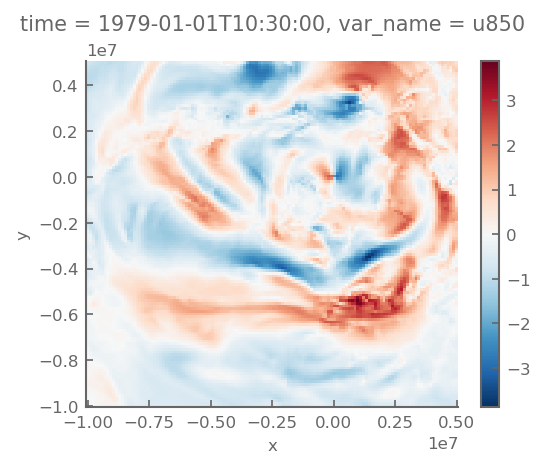

In [15]:
((ds.u850.isel(time=0) - ds.data_mean.sel(var_name='u850'))/ds.data_std.sel(var_name='u850')).plot()

In [6]:
data_mean = ds[['u850', 'v850', 'x850', 'y850', 'z500', 'msl', 'tcwv']].sel(time=slice('1979','2008')).to_array('var_name').mean(['time',]).load()
data_std = ds[['u850', 'v850', 'x850', 'y850', 'z500', 'msl', 'tcwv']].sel(time=slice('1979','2008')).to_array('var_name').std(['time']).load()

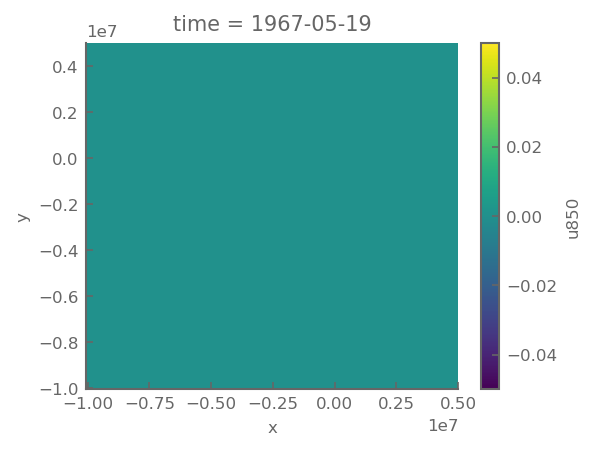

In [11]:
ds['u850'].isel(time=10000).plot()

In [25]:
data_mean.attrs['train_period'] = '1979-2009'
data_std.attrs['train_period'] = '1979-2009'

In [28]:
ds['data_mean'] = data_mean
ds['data_std'] = data_std
ds.to_zarr('/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS.zarr', mode='w')

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [2]:
# run_id = '3w874ud3'
# run_id = '0obl1joe'
run_id = '75kakckt'
# ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_attributions.nc', chunks = dict(time_of_event=20)).load()
ds_predictions = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_model_skill.nc')
ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_ALL_attributions_v2.nc').transpose('y','x',...)
ds_moran = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_moranI_lrp_normed_v2.nc') 
ds_attrs['moran_I'] = ds_moran.Moran_I

lrp_normed = ds_attrs.attributions_lrp 
lrp_normed = lrp_normed.sum('var_name')/lrp_normed.sum('var_name').clip(0).sum(['x','y'])
ds_attrs['lrp_normed'] = lrp_normed

# ig_normed = ds_attrs.attributions_ig 
# ig_normed = ig_normed/ig_normed.sum('var_name').max(['x','y'])
# # cycs = cycs.query("msl<100000")
gdf_cyclones = gpd.read_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data.geojson')
gdf_cyclones['blob_pixel_count'] = (gdf_cyclones.blob_area/1.384083e+04).round(1)

In [3]:
all_cyclones = gpd.read_file('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/all_cyclones.geojson')

# Plot 0: model skill

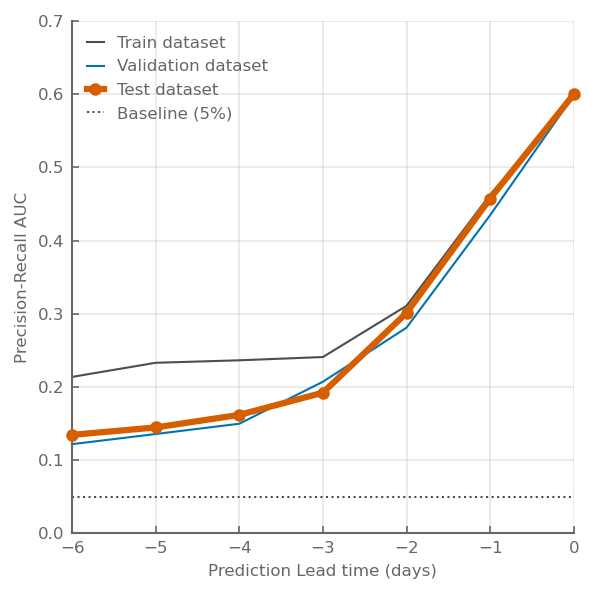

In [4]:
auc_train = []
auc_val = []
auc_test = []

for k in range(7):
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='train').targets.dropna('time')[:,k], ds_predictions.sel(dataset='train').predictions.dropna('time')[:,k])
    auc_train.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='val').targets.dropna('time')[:,k], ds_predictions.sel(dataset='val').predictions.dropna('time')[:,k])
    auc_val.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='test').targets.dropna('time')[:,k], ds_predictions.sel(dataset='test').predictions.dropna('time')[:,k])
    auc_test.append(sklearn.metrics.auc(r,p))

fig, ax = plt.subplots(figsize=(4,4,))

ax.plot(np.arange(0,-7,-1),auc_train, color='.3', label='Train dataset')
ax.plot(np.arange(0,-7,-1),auc_val, label='Validation dataset')
ax.plot(np.arange(0,-7,-1),auc_test, color='C3', lw=3, label='Test dataset', marker='o', markersize=5, clip_on=False, zorder=100)
ax.grid(ls='-', alpha=.3)
ax.axhline(0.05,color='.3' , label='Baseline (5%)', ls=':')
ax.set_xlim(-6,0)
ax.set_ylim(0,0.7)
ax.legend()
ax.set_ylabel('Precision-Recall AUC')
ax.set_xlabel('Prediction Lead time (days)')
plt.tight_layout()
plt.savefig('plots/model_skill_PR-AUC.svg', dpi=300, transparent=True)

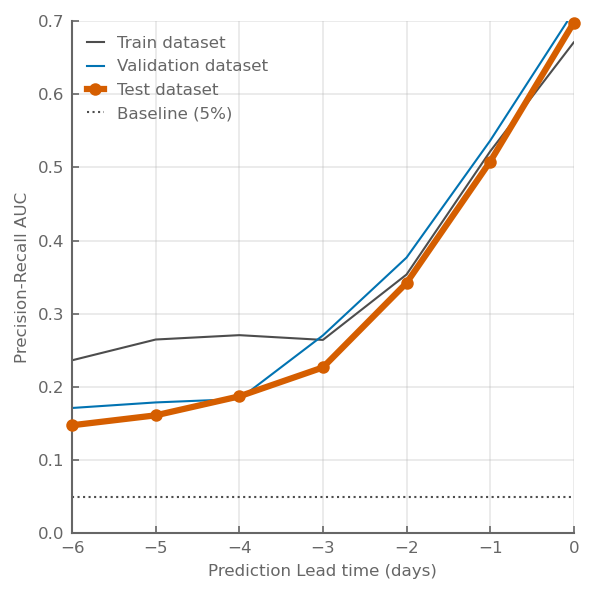

In [5]:
auc_train = []
auc_val = []
auc_test = []

for k in range(7):
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='train').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='train').predictions.dropna('time')[:,k])
    auc_train.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='val').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='val').predictions.dropna('time')[:,k])
    auc_val.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='test').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.time.dt.season=='DJF').sel(dataset='test').predictions.dropna('time')[:,k])
    auc_test.append(sklearn.metrics.auc(r,p))

fig, ax = plt.subplots(figsize=(4,4,))

ax.plot(np.arange(0,-7,-1),auc_train, color='.3', label='Train dataset')
ax.plot(np.arange(0,-7,-1),auc_val, label='Validation dataset')
ax.plot(np.arange(0,-7,-1),auc_test, color='C3', lw=3, label='Test dataset', marker='o', markersize=5, clip_on=False, zorder=100)
ax.grid(ls='-', alpha=.3)
ax.axhline(0.05,color='.3' , label='Baseline (5%)', ls=':')
ax.set_xlim(-6,0)
ax.set_ylim(0,0.7)
ax.legend()
ax.set_ylabel('Precision-Recall AUC')
ax.set_xlabel('Prediction Lead time (days)')
plt.tight_layout()

<Axes: xlabel='month'>

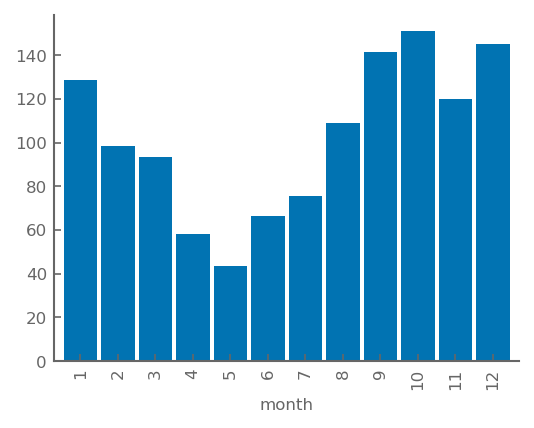

In [6]:
(ds_predictions.predictions.max('dataset').isel(timestep=0).where(ds_predictions.predictions.max('dataset').isel(timestep=0)>0.5).groupby('time.month').count()/7).to_series().plot.bar(width=.9)

0.5957184303830559
0.46272025139175066
0.31086837801621076
0.24090667504873142
0.2364478062597061
0.23305742711760288
0.21378528796604804


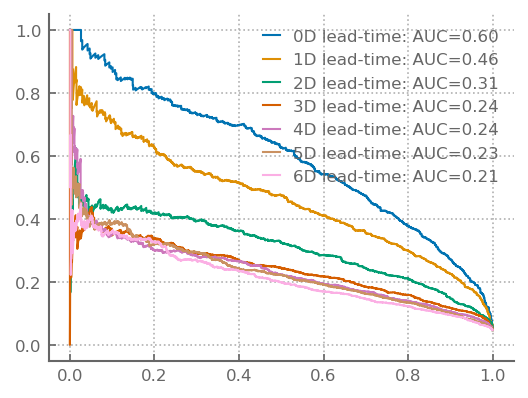

In [7]:
fig, axs = plt.subplots()
import sklearn 
for k in range(7):
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.sel(dataset='train').targets.dropna('time')[:,k], ds_predictions.sel(dataset='train').predictions.dropna('time')[:,k])
    plt.plot(r,p, label=f'{k}D lead-time: AUC={sklearn.metrics.auc(r,p):.02f}')
    print(sklearn.metrics.auc(r,p))
plt.grid()
plt.legend()

# targets

# Plot 1: attributions are aggregated

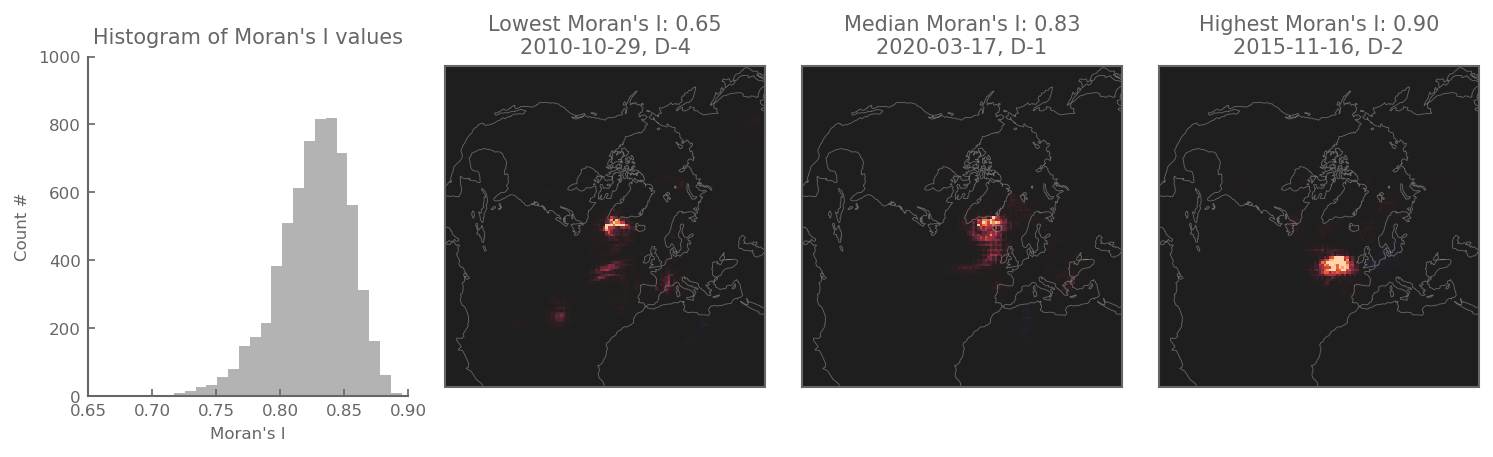

In [8]:
# print(ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmax().values)
# print(ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmin().values)
fig, axs = plt.subplot_mosaic("""ABCD""", figsize=(10,3), 
                              per_subplot_kw=dict(BCD=dict(projection=proj)))
ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmax()

ds_attrs.moran_I.plot.hist(ax=axs['A'], bins=30, color='.7')
ds_attrs.sel(time_of_event='2010-10-29', timestep_past=-4).lrp_normed.plot(ax=axs['B'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.008)
ds_attrs.sel(time_of_event='2020-03-17', timestep_past=-1).lrp_normed.plot(ax=axs['C'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.008)
ds_attrs.sel(time_of_event='2015-11-16', timestep_past=-2).lrp_normed.plot(ax=axs['D'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.008)


lowest_moran = ds_attrs.sel(time_of_event='2010-10-29', timestep_past=-4).moran_I.values
median_moran = ds_attrs.sel(time_of_event='2020-03-17', timestep_past=-1).moran_I.values
highest_moran = ds_attrs.sel(time_of_event='2015-11-16', timestep_past=-2).moran_I.values

for letter in 'BCD':
    axs[letter].coastlines(color='.7', lw=.4, alpha=.5)
axs['A'].set_title('Histogram of Moran\'s I values')
axs['A'].set(xlabel="Moran's I", ylabel='Count #', xlim=(.65,.9), ylim=(0,1000))
axs['B'].set_title(f'Lowest Moran\'s I: {lowest_moran:.02f}\n2010-10-29, D-4')
axs['C'].set_title(f'Median Moran\'s I: {median_moran:.02f}\n2020-03-17, D-1')
axs['D'].set_title(f'Highest Moran\'s I: {highest_moran:.02f}\n2015-11-16, D-2')
plt.tight_layout()
plt.savefig('plots/moranI_examples_lrp_normed_v2.png', dpi=300, transparent=True)

# Plot 2: example to get to blobs and cyclones

/tmp/ipykernel_492951/2037617340.py:13: FutureWarning: The behavior of 'isin' with dtype=datetime64[ms] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  gdf_cyclones_event = gdf_cyclones.query("time_of_event=='2024-12-18' and timestep_past==-2")
/tmp/ipykernel_492951/2037617340.py:14: FutureWarning: The behavior of 'isin' with dtype=datetime64[ms] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  cyclones_day = all_cyclones.query("date=='2024-12-16'")
/tmp/ipykernel_492951/2037617340.py:15: FutureWarning: The behavior of 'isin' with dtype=datetime64[ms] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype 

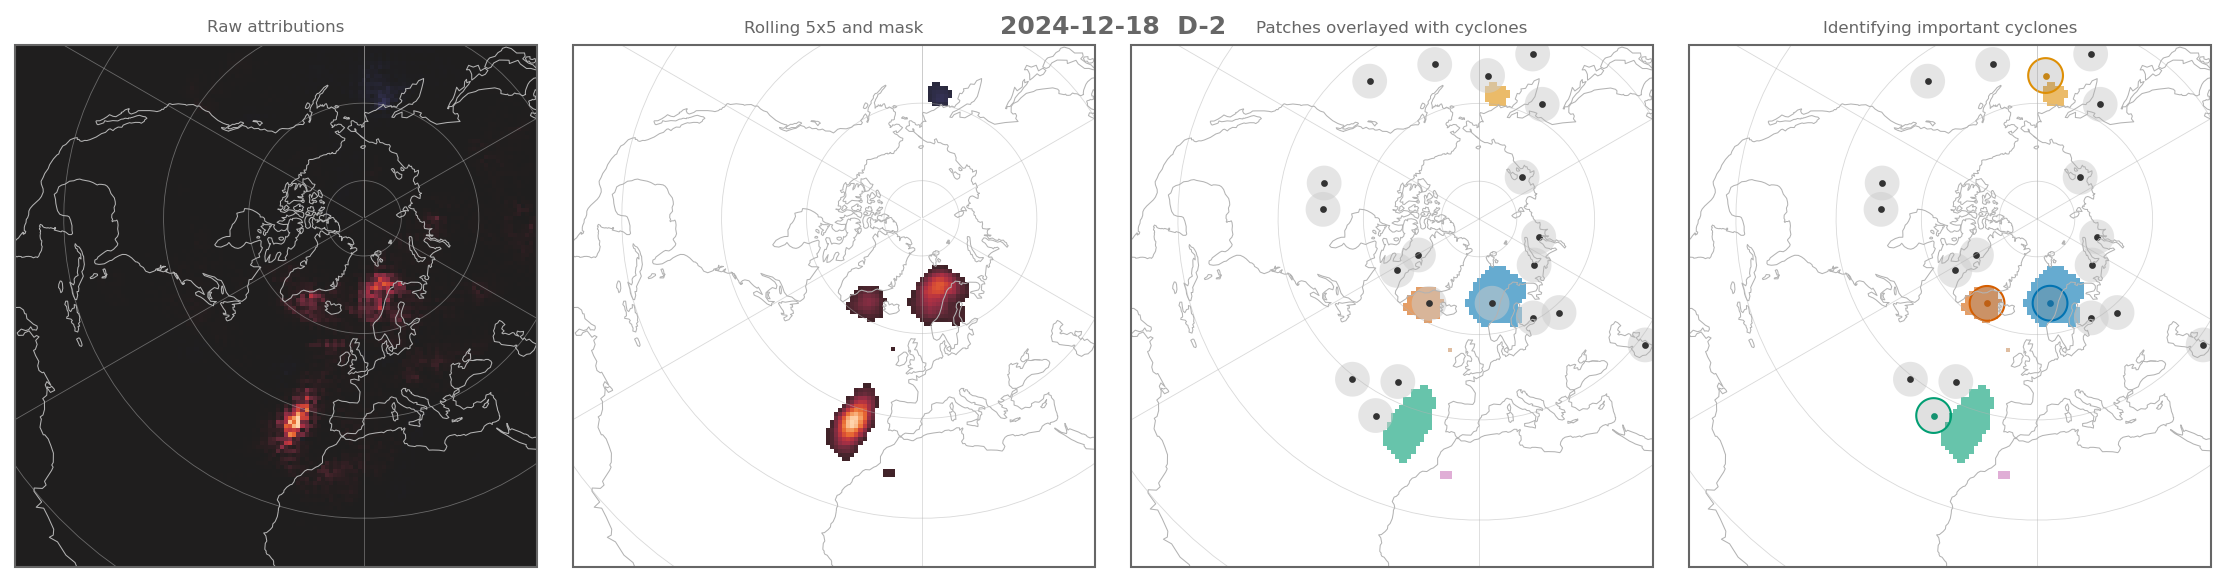

In [9]:
fig, axs = plt.subplot_mosaic("""ABCD""",figsize=(15,4), per_subplot_kw=dict(ABCD=dict(projection=proj)))
data = ds_attrs.lrp_normed.sel(time_of_event='2024-12-18', timestep_past=-2)

data.plot(cmap='icefire', ax=axs['A'], transform=proj, add_colorbar=False)

rolling=5
abs_threshold=0.0005
data_rolling = data.rolling(x=rolling,y=rolling,center=True).mean().fillna(0)
data_rolling = data_rolling.where(np.abs(data_rolling)>abs_threshold)
data_rolling = data_rolling/data_rolling.max()
data_rolling.plot(cmap='icefire', ax=axs['B'], transform=proj, add_colorbar=False)

gdf_cyclones_event = gdf_cyclones.query("time_of_event=='2024-12-18' and timestep_past==-2")
cyclones_day = all_cyclones.query("date=='2024-12-16'")
cyclone_blobs = all_cyclones.query("date=='2024-12-16'").set_index('track_id').loc[gdf_cyclones_event.query("is_cyclone").cyclone_track_id.values.astype(float)]
cyclone_no_blobs = all_cyclones.query("date=='2024-12-16'").set_index('track_id').drop(cyclone_blobs.index)


axs['C'].set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)
axs['D'].set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)

# sns.scatterplot(all_cyclones.query("date=='2024-12-16'"), x='x', y='y', ax=axs['D'], transform=proj)
for k in range(gdf_cyclones_event.index.size):
    line = gdf_cyclones_event.iloc[k:k+1]
    line.plot(color=f"C{k}", ax=axs['C'], transform=proj, alpha=.6)
    # if line.cyclone_track_id.values[0]!='No cyclone':
    #     cyclone_ = cyclone_blobs.loc[line.cyclone_track_id.astype(float).values]
    #     cyclone_.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color=f'C{k}')
    #     cyclone_.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)
    #     cyclone_.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='none',edgecolor=f'C{k}', )
        # cyclone_.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)

cyclones_day.query("date=='2024-12-16'").geometry.buffer(500_000).plot(aspect=1, ax=axs['C'], transform=proj, color='.8', alpha=.5)
cyclones_day.query("date=='2024-12-16'").geometry.plot(aspect=1, ax=axs['C'], transform=proj, markersize=5, color='.2')

for k in range(gdf_cyclones_event.index.size):
    line = gdf_cyclones_event.iloc[k:k+1]
    line.plot(color=f"C{k}", ax=axs['D'], transform=proj, alpha=.6)
    if line.cyclone_track_id.values[0]!='No cyclone':
        cyclone_ = cyclone_blobs.loc[line.cyclone_track_id.astype(float).values]
        cyclone_.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color=f'C{k}')
        cyclone_.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)
        cyclone_.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='none',edgecolor=f'C{k}', )
        # cyclone_.geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.4', alpha=.2)

cyclone_no_blobs.query("date=='2024-12-16'").geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='.8', alpha=.5)
cyclone_no_blobs.query("date=='2024-12-16'").geometry.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color='.2')

# cyclone_blobs.query("date=='2024-12-16'").geometry.plot(aspect=1, ax=axs['D'], transform=proj, markersize=15, color='C3')
# cyclone_blobs.query("date=='2024-12-16'").geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, color='none',edgecolor='.3')

for letter in 'ABCD':
    ax = axs[letter]
    ax.set_title('')
    ax.coastlines(color='.7', lw=.5)
    # sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,       # add tick labels
        linewidth=0.4,
        linestyle="-",
        alpha=0.5,
        zorder=2,
        color='.7'
    )
axs['A'].set_title('Raw attributions', size=8)
axs['B'].set_title('Rolling 5x5 and mask', size=8)
axs['C'].set_title('Patches overlayed with cyclones', size=8)
axs['D'].set_title('Identifying important cyclones', size=8)

plt.suptitle('2024-12-18  D-2', weight = 'bold', size=12, y=.95)
plt.tight_layout()
plt.savefig('plots/example_workflow.png', dpi=300, transparent=True)

# Plot 3.0: patches distribution


/tmp/ipykernel_492951/236163601.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = gdf_cyclones.groupby([pd.cut(gdf_cyclones.blob_pixel_count, np.arange(0,1001,5)),


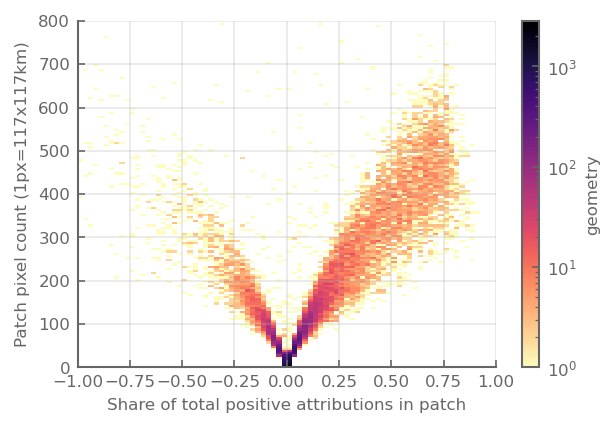

In [10]:
fig, ax = plt.subplots(figsize=(4.5,3))
df_plot = gdf_cyclones.groupby([pd.cut(gdf_cyclones.blob_pixel_count, np.arange(0,1001,5)),
                      pd.cut(gdf_cyclones.blob_attributions, np.arange(-1.5,1.1, .025)),
                      ]).geometry.count().to_xarray()
df_plot.where(df_plot>=1).plot(norm=LogNorm(), vmin=1, cmap='magma_r')
ax.grid(linestyle='-', alpha=.3, zorder=10)
ax.set(ylim=(0,800), xlim=(-1,1))
# ax.set_ylim(0,50)
ax.set_ylabel('Patch pixel count (1px=117x117km)')
ax.set_xlabel('Share of total positive attributions in patch')
plt.savefig('plots/patches_distributions.png', dpi=300, transparent=True)

# Plot 3: there are usually 1-3 large blobs per prediction
"Large blobs" are defined as 25pixels minimum (5x5 square)

In [11]:
categories = np.array(['                     ' for k in gdf_cyclones.index])
categories[((gdf_cyclones.blob_pixel_count<25)).values] = 'small blob'
categories[((np.abs(gdf_cyclones.blob_attributions)<.05)&(gdf_cyclones.blob_pixel_count>=25)).values] = 'large neutral'
categories[((gdf_cyclones.blob_attributions<-.05)&(gdf_cyclones.blob_pixel_count>=25)).values] = 'large negative'
categories[((gdf_cyclones.blob_attributions>.05)&(gdf_cyclones.blob_pixel_count>=25)).values] = 'large positive'
gdf_cyclones['blob_category'] = categories
# gdf_cyclones.category.value_counts().plot.bar()

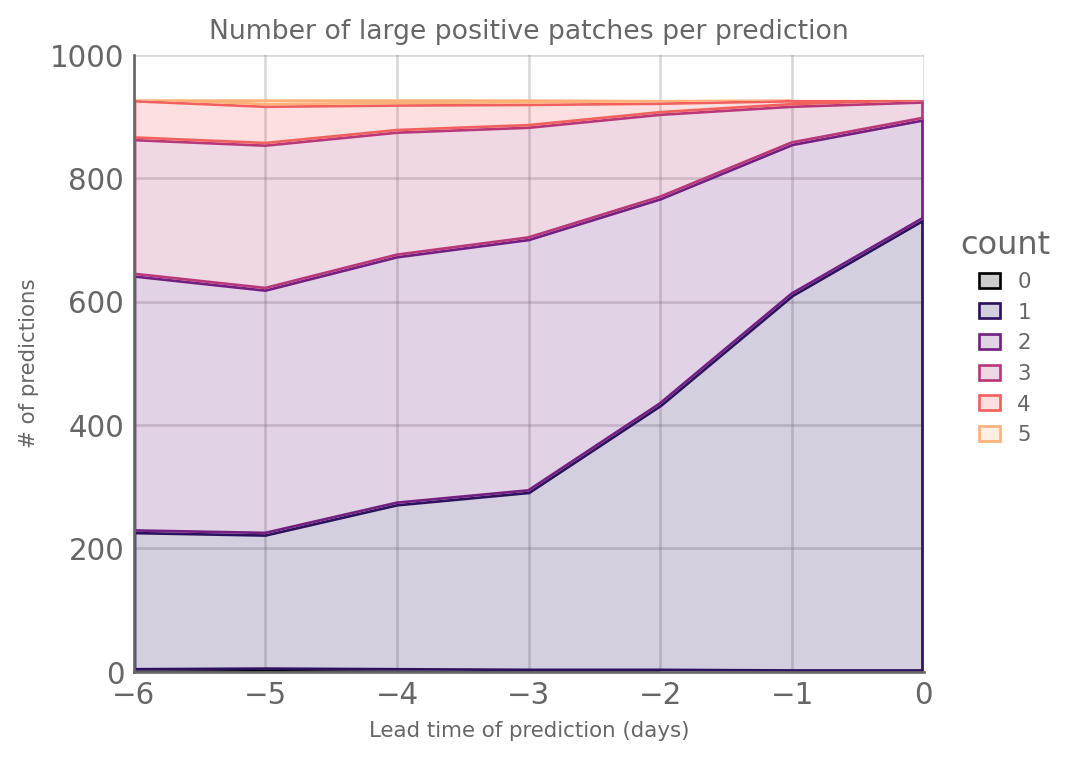

In [12]:
df_plot = gdf_cyclones.query("blob_category=='large positive'").groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')
df_count_all = gdf_cyclones.groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')*0
df_count_all.loc[df_plot.index] =df_plot
df_plot = df_count_all.reset_index()

(so.Plot(df_plot, x='timestep_past', color='count')
 .add(so.Area(), so.Count(), so.Stack(), legend=True)
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
#  .add(so.Dot(), so.Count(), so.Stack())
#  .facet(col='blo_category')
 .scale(color=so.Nominal(['0']+list(sns.color_palette('magma', n_colors=5)), order=[0,1,2,3,4,5], ) )
 .layout(size=(5,4))
 .limit(x=(-6,0), y=(0,1000))
 .label(title='Number of large positive patches per prediction', y='# of predictions', x='Lead time of prediction (days)', legend='Number of large positive blobs')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).plot().save('plots/N_large_patches_per_predictions.svg', dpi=300, transparent=True)

# plt.savefig('plots/N_large_patches_per_predictions.png', dpi=300, transparent=True)

# Plot 4: large blobs are almost always associated with cyclones

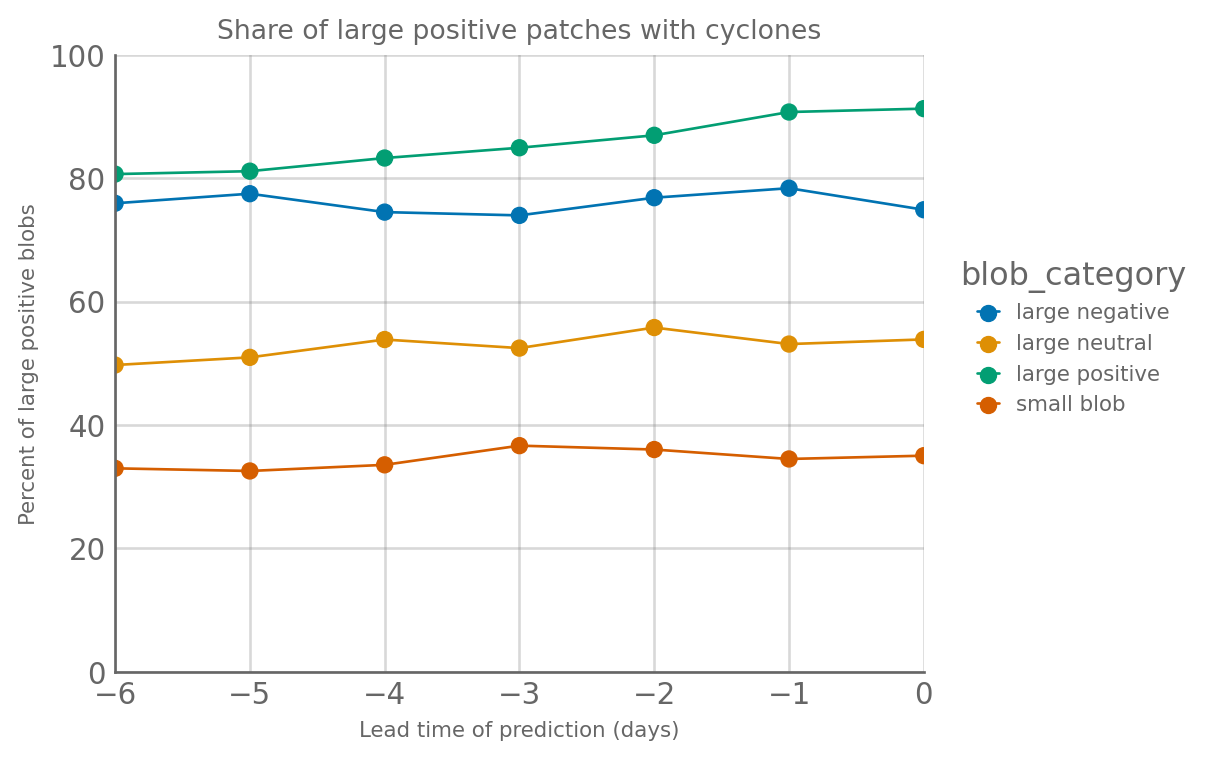

In [13]:
df_plot = (100*(gdf_cyclones.query("is_cyclone").groupby(["blob_category","timestep_past",]).blob_area.count().rename('count'))/(gdf_cyclones.groupby(["blob_category","timestep_past",]).blob_area.count().rename('count'))).rename('percentage').reset_index()

df_plot

(so.Plot(df_plot, x='timestep_past', color='blob_category', y='percentage')
 .add(so.Line(),  legend=True)
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
 .add(so.Dot(),)
#  .facet(col='blob_category')
#  .scale(color=so.Nominal(['0', 'C3']  ) )
 .layout(size=(5,4))
 .limit(x=(-6,0), y=(0,100))
 .label(title='Share of large positive patches with cyclones', y='Percent of large positive blobs', x='Lead time of prediction (days)', legend='Number of large positive blobs', yticks= '{.0f%}%')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).plot().save('plots/share_of_patches_with_cyclones.svg', dpi=300, transparent=True)


# Plot 5: there are usually 1-2 cyclones used per prediction

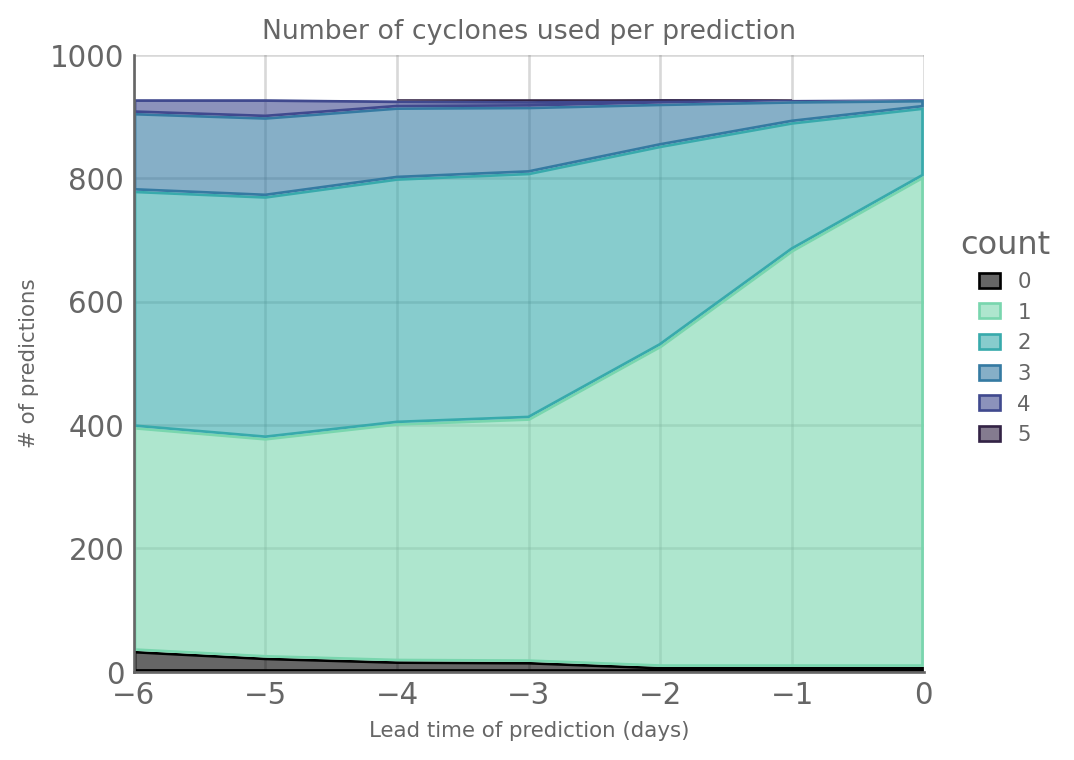

In [14]:
df_plot = gdf_cyclones.query("(blob_category=='large positive') & (is_cyclone)").groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')
df_count_all = gdf_cyclones.groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')*0
df_count_all.loc[df_plot.index] =df_plot
df_plot = df_count_all.reset_index()

(so.Plot(df_plot, x='timestep_past', color='count')
 .add(so.Area( alpha=.6), so.Count(), so.Stack(), legend=True,)
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
#  .add(so.Dot(), so.Count(), so.Stack())
#  .facet(col='blo_category')
 .scale(color=so.Nominal(['0']+list(sns.color_palette('mako_r', n_colors=5)), order=[0,1,2,3,4,5], ) )
 .layout(size=(5,4))
 .limit(x=(-6,0), y=(0,1000))
 .label(title='Number of cyclones used per prediction', y='# of predictions', x='Lead time of prediction (days)', legend='Number of large positive blobs')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).plot().save('plots/cyclones_in_patches_per_prediction.svg', dpi=300, transparent=True)



# Cyclones are in the right place
need map here

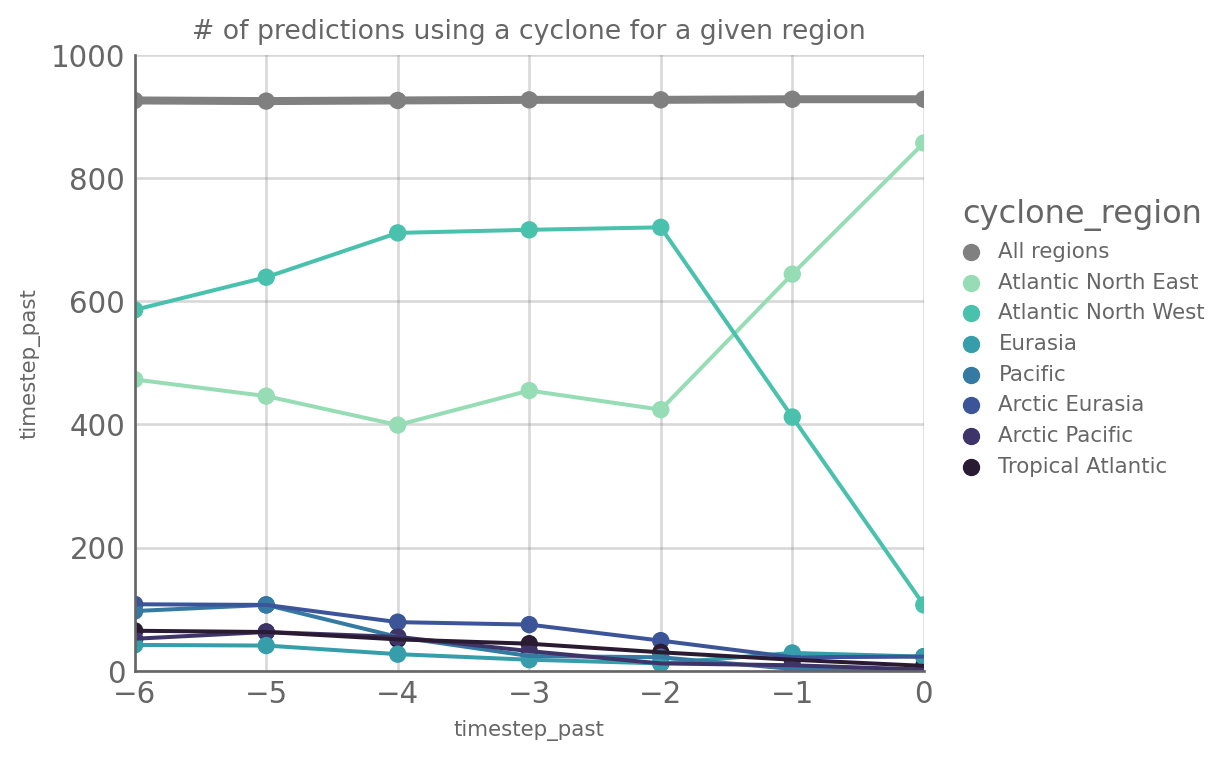

In [17]:
df_counts = gdf_cyclones.reset_index().query("blob_category=='large positive'").groupby(['time_of_event','timestep_past','cyclone_region']).cyclone_msl.count().reset_index()
df_all_counts = gdf_cyclones.reset_index().query("blob_category=='large positive'").groupby(['time_of_event','timestep_past']).cyclone_msl.count().reset_index()
df_all_counts['cyclone_region'] = 'All regions'
df_counts = pd.concat([df_counts, df_all_counts])

(so.Plot(df_counts, x='timestep_past', color='cyclone_region', linewidth='cyclone_region', y='timestep_past')
 .add(so.Lines(), so.Count(),  legend=False)
#  .add(so.Line(linewidth=3), so.Count(), , data=df_all_counts)
 .add(so.Dot(), so.Count(), )
#  .facet(col='blo_category')
 .scale(color=so.Nominal(['.5']+ sns.color_palette('mako_r', n_colors=7),order=['All regions','Atlantic North East','Atlantic North West',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic']),
       linewidth=so.Nominal([1.5,1.5,1.5,1.5,1.5,1.5,1.5,3],order=['Atlantic North West','Atlantic North East',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic','All regions'])
       )

 .layout(size=(5,4))
  .limit(x=(-6,0), y=(0,1000))
 .label(title='# of predictions using a cyclone for a given region')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 .label(legend="Measurement")
 ).plot().save('plots/cyclone_area.svg', dpi=300, transparent=True)


# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)


In [18]:
df_counts.query('timestep_past==-6').groupby(['cyclone_region']).timestep_past.count().sort_values(ascending=False).iloc[1:]

cyclone_region
Atlantic North West    586
Atlantic North East    473
Arctic Eurasia         108
Pacific                 97
Tropical Atlantic       65
Arctic Pacific          52
Eurasia                 42
Name: timestep_past, dtype: int64

In [16]:
gdf_cyclones.time_of_event.unique()

<DatetimeArray>
['1979-01-07 00:00:00', '1979-03-03 00:00:00', '1979-03-04 00:00:00',
 '1979-03-05 00:00:00', '1979-08-14 00:00:00', '1979-09-11 00:00:00',
 '1979-09-13 00:00:00', '1979-09-17 00:00:00', '1979-09-18 00:00:00',
 '1979-09-19 00:00:00',
 ...
 '2024-10-23 00:00:00', '2024-10-22 00:00:00', '2024-10-27 00:00:00',
 '2024-10-31 00:00:00', '2024-11-16 00:00:00', '2024-12-01 00:00:00',
 '2024-12-13 00:00:00', '2024-12-15 00:00:00', '2024-12-18 00:00:00',
 '2024-12-29 00:00:00']
Length: 928, dtype: datetime64[ms]

/tmp/ipykernel_397676/1994135658.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = pos_blob_cycs.groupby(["timestep_past","time_of_event",
/tmp/ipykernel_397676/1994135658.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = df_.groupby(['timestep_past','cyclone_lon','cyclone_lat'])['count'].sum().reset_index()


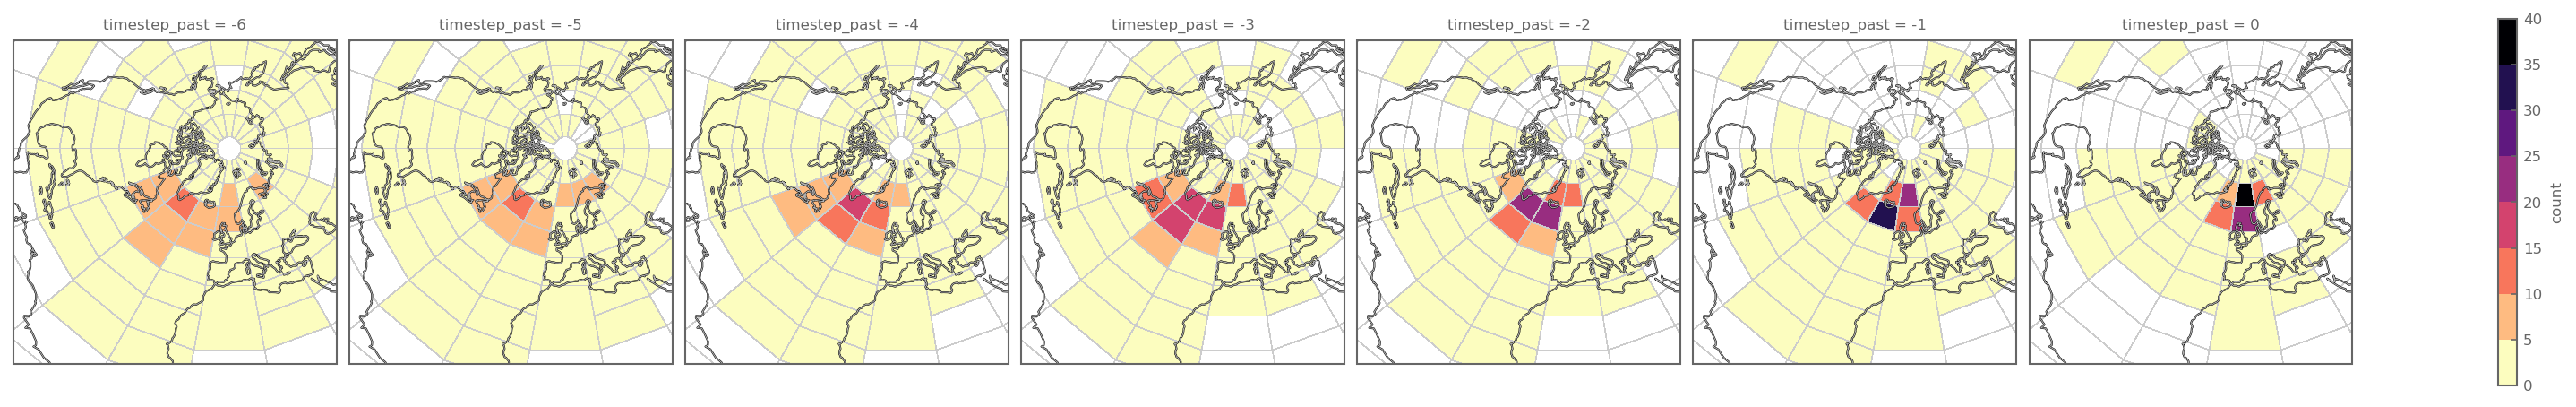

In [17]:
pos_blob_cycs = gdf_cyclones.query("is_cyclone&(blob_category=='large positive')")
df_ = pos_blob_cycs.groupby(["timestep_past","time_of_event", 
                       pd.cut(pos_blob_cycs.cyclone_lon, np.arange(-190,181,20)),
                       pd.cut(pos_blob_cycs.cyclone_lat, np.arange(-45,91,10))]).geometry.count().rename('count').reset_index()
df_['count_one'] = df_['count']>0
df_ = df_.groupby(['timestep_past','cyclone_lon','cyclone_lat'])['count'].sum().reset_index()
df_['cyclone_lon'] = [k.mid for k in df_.cyclone_lon]
df_['cyclone_lat'] = [k.mid for k in df_.cyclone_lat]

ds_ = df_.set_index(['timestep_past','cyclone_lon','cyclone_lat'])['count'].to_xarray()/928*100

plot = ds_.where(ds_>0).plot(col='timestep_past', transform = ccrs.PlateCarree(),
         subplot_kws=dict(projection=proj), x='cyclone_lon', y='cyclone_lat', cmap='magma_r',
         levels=[0,5,10,15,20,25,30,35,40], edgecolors='.8', linewidth=.3)

for ax in plot.axs.flatten():
    ax.coastlines()
    ax.set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)
    ax.coastlines(color='.7', lw=.5)
    # sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
    # gl = ax.gridlines(
    #     crs=ccrs.PlateCarree(),
    #     draw_labels=False,       # add tick labels
    #     linewidth=0.4,
    #     linestyle="-",
    #     alpha=0.5,
    #     zorder=2,
    #     color='.7'
    # )
    # gl.ylines=False


In [162]:
all_cyclones

,date,track_id,msl,lon,lat,x,y,key,geometry
0,1979-01-01,0.0,100487.303602,-76.048833,45.989150,-4.859531e+06,-1.207219e+06,1979-01-01 0.0,POINT (-4859530.96139 -1207218.83636)
1,1979-01-01,101.0,97338.043428,122.049854,74.149758,1.464296e+06,9.167662e+05,1979-01-01 101.0,POINT (1464295.96158 916766.24675)
2,1979-01-01,67.0,98855.651712,22.982749,46.559554,1.927227e+06,-4.544065e+06,1979-01-01 67.0,POINT (1927226.7302 -4544065.05764)
3,1979-01-01,63.0,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06,1979-01-01 63.0,POINT (1089235.31533 -5095836.51674)
4,1979-01-01,22.0,100754.987498,73.433667,48.961326,4.445745e+06,-1.322490e+06,1979-01-01 22.0,POINT (4445744.6143 -1322490.06499)
...,...,...,...,...,...,...,...,...,...
290206,2024-12-30,955856.0,100503.970350,-102.183367,57.591066,-3.522528e+06,7.605272e+05,2024-12-30 955856.0,POINT (-3522528.20672 760527.22572)
290207,2024-12-30,955852.0,101709.656783,6.671551,19.660674,1.011669e+06,-8.648989e+06,2024-12-30 955852.0,POINT (1011669.11336 -8648988.53791)
290208,2024-12-30,955944.0,96591.911384,24.654133,71.221191,8.559414e+05,-1.864881e+06,2024-12-30 955944.0,POINT (855941.38005 -1864881.02438)
290209,2024-12-31,955936.0,97715.058098,170.721027,60.375923,5.288183e+05,3.236749e+06,2024-12-31 955936.0,POINT (528818.29025 3236748.6743)


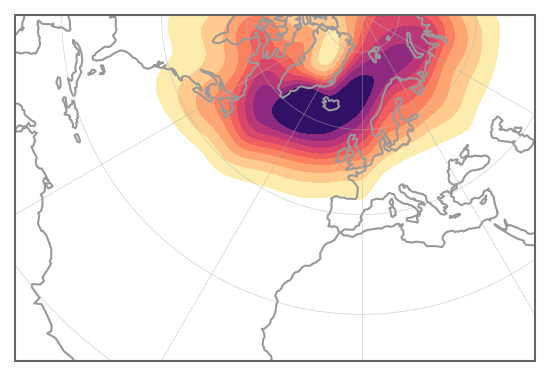

In [167]:
fig, ax = plt.subplots(figsize=(6,3),subplot_kw = dict(projection=proj))
sns.kdeplot(pos_blob_cycs, x='x', y='y', fill=True, transform=proj, cmap='magma_r')
ax.set_extent([-1e7, 5e6, -1e7, 0e6], crs=proj)
ax.coastlines(color='.6', lw=1)
# sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,       # add tick labels
    linewidth=0.4,
    linestyle="-",
    alpha=0.5,
    zorder=2,
    color='.7'
)


/tmp/ipykernel_397676/4051974330.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = pos_blob_cycs.groupby([


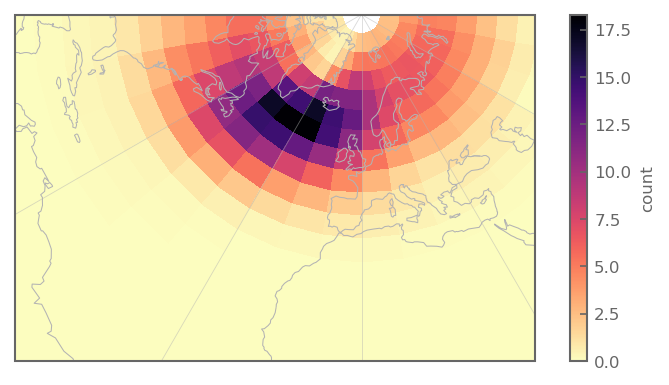

In [157]:
pos_blob_cycs = all_cyclones.query("lat>0").query("msl<99000")
df_ = pos_blob_cycs.groupby([ 
                       pd.cut(pos_blob_cycs.lon, np.arange(-190,181,10)),
                       pd.cut(pos_blob_cycs.lat, np.arange(-45,91,5))]).geometry.count().rename('count').reset_index()
df_['lon'] = [k.mid for k in df_.lon]
df_['lat'] = [k.mid for k in df_.lat]

ds_ = df_.set_index(['lon','lat'])['count'].to_xarray()/46

plot = ds_.rolling(lon=3, lat=3, center=True).mean().ffill('lon').bfill('lon').plot( transform = ccrs.PlateCarree(),
         subplot_kws=dict(projection=proj), x='lon', y='lat', cmap='magma_r',
         edgecolors='none', linewidth=.3, aspect=2, size=3)

# for ax in plot.axes.flatten():
ax = plot.axes
ax.set_extent([-1e7, 5e6, -1e7, 0e6], crs=proj)
ax.coastlines(color='.7', lw=.5)
# sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,       # add tick labels
    linewidth=0.4,
    linestyle="-",
    alpha=0.5,
    zorder=2,
    color='.7'
)
gl.ylines=False


In [145]:
df = pd.read_csv('/home/rogui7909/code/predict_rain_norway/bonus/table(5).csv', sep=';', decimal=",").dropna()
df = df.iloc[:,[0,2,3]].dropna()
df.columns = ['station','time','pr']
df['time'] = pd.to_datetime(df.time, format = "%d.%m.%Y",)
df = df.set_index(['time','station'])
df['pr'] = df.pr.astype(float).clip(0)
df['pr'] = df['pr'].where(df['pr']>0).fillna(0)
df = df.unstack().pr.loc['2000':'2024']

In [ ]:
df.dropna().mean()*365.25

Bergen - Florida
(1, 1000]    13.522245
(-1, 1]      11.477070
Name: count, dtype: float64

In [153]:
pd.cut(df.iloc[:,0], [-1,1,1000]).value_counts()/25

Bergen - Florida
(1, 1000]    197.56
(-1, 1]      167.68
Name: count, dtype: float64

IndexError: tuple index out of range

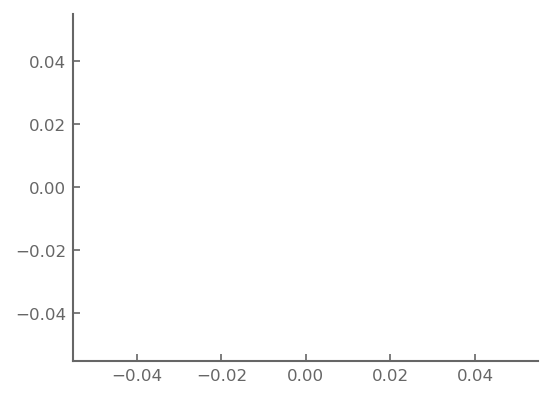

In [110]:
df.pr.plot.hist(bins=[0])